# Data Selection

The data selected for this project comes from kaggle, created by Sarvesh Chhetri and available in the following link: 
https://www.kaggle.com/datasets/sarveshchhetri/student-lifestyle-vs-academic-performance-dataset?resource=download


This dataset captures a simulation of 8,000 university students with a wide variety of academic, behavioral and socioeconomic attributes.

The dataset has two versions: The one that classifies the target variable *grade* in a range from A-C, and the second one that has a numeric float value in the *grade* column.

This project will use the one that has the A-C classification (student_performance_grade.csv). So the model will be a classifier.


# Data Preprocessing

Data is preprocessed the following way:
- First, check for missing values
- Checking the distribution of the target variable is important to understand class balance
- Removal of information not important for the model (Student ID column)
- Encoding of the *grade* column so that string values can be transformed into their own, int classes
- Split the train and test sets with an 80/20 distribution
- Detect numeric and categorical columns
- One Hot Encoding for categorical columns
- Normalize numeric variables

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import numpy as np



Missing values:
Student_ID                    0
Age                           0
Gender                        0
Hours_Studied                 0
Attendance                    0
Sleep_Hours                   0
Stress_Level                  0
Screen_Time                   0
Previous_GPA                  0
Part_Time_Job                 0
Study_Method                  0
Diet_Quality                  0
Internet_Quality              0
Extracurricular               0
Tutoring_Sessions_Per_Week    0
Family_Income_Level           0
Exam_Anxiety_Score            0
Grade                         0
dtype: int64

Grade distribution:
Grade
A       4475
B       2212
C       1053
D        226
Fail      34
Name: count, dtype: int64


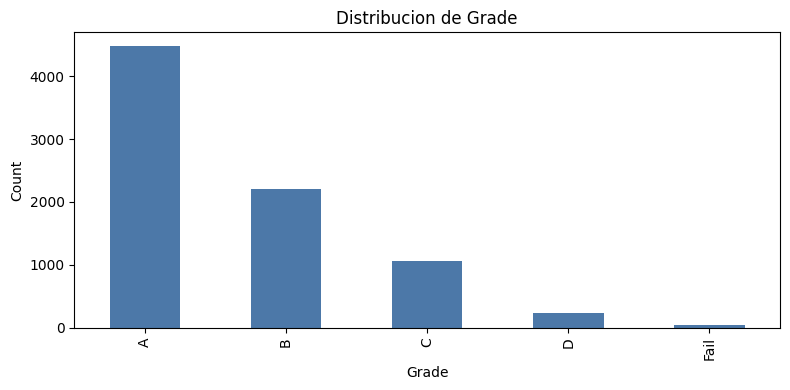

In [16]:
csv_path = 'student_performance_grade.csv'
df = pd.read_csv(csv_path)

# Check for missing values to see if some cleaning is needed before modeling
print('\nMissing values:')
print(df.isna().sum())

# Checking the distribution of the target variable 'Grade' to understand class balance
print('\nGrade distribution:')
print(df['Grade'].value_counts().sort_index())

plt.figure(figsize=(8, 4))
df['Grade'].value_counts().sort_index().plot(kind='bar', color='#4c78a8')
plt.title('Distribucion de Grade')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



## Missing values and class balance

As shown, the dataset has no missing values, so further cleansing is not needed. However, the dataset proves to have a lot of class imbalances, since the grade 'A' has much more instances than 'Fail' for example.

In [17]:

# Remove the student ID, since it is not useful information and split features from the target variable
df_model = df.drop(columns=['Student_ID']).copy()
X = df_model.drop(columns=['Grade'])
y = df_model['Grade']

# Encode the target, so  the problem turns into a classification task with numeric labels.
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split train and test sets, aiming to keep the class balance in both sets using stratification.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)

# Search for numeric and categorical features to apply the appropriate transformations to each type.
numeric_features = X.select_dtypes(include='number').columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'string']).columns.tolist()

# Create the oneHotEncoder to transform categorical features
try:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse=False)

# Create the preprocessor to actually apply the transformations to the appropriate features
# Normalize the numeric data and one-hot encode the categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', one_hot, categorical_features),
    ]
)

# Preprocess the train set.
X_train_processed = preprocessor.fit_transform(X_train)

# Preprocess the test set, so just data transformation without fitting, to avoid data leakage.
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()
X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

print('Train shape:', X_train_processed.shape, y_train.shape)
print('Test shape:', X_test_processed.shape, y_test.shape)
print('Processed features:')
display(X_train_processed.head())

Train shape: (6400, 29) (6400,)
Test shape: (1600, 29) (1600,)
Processed features:


,num__Age,num__Hours_Studied,num__Attendance,num__Sleep_Hours,num__Stress_Level,num__Screen_Time,num__Previous_GPA,num__Tutoring_Sessions_Per_Week,num__Exam_Anxiety_Score,cat__Gender_Female,...,cat__Diet_Quality_Poor,cat__Internet_Quality_Average,cat__Internet_Quality_Excellent,cat__Internet_Quality_Good,cat__Internet_Quality_Poor,cat__Extracurricular_No,cat__Extracurricular_Yes,cat__Family_Income_Level_High,cat__Family_Income_Level_Low,cat__Family_Income_Level_Middle
1352,1.527844,-0.263761,-0.664850,0.000955,-0.374323,0.454616,0.867377,0.262394,-0.064009,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
5964,-1.090615,-0.786194,-0.592392,1.341270,0.092153,-0.958666,-0.936209,1.162354,0.764535,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
6589,1.527844,-0.325224,0.484134,-0.836741,-0.529815,-0.622170,0.805891,0.262394,-0.359917,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4000,1.091434,0.437938,-1.772430,-0.836741,1.180597,-0.285674,0.027070,-1.537525,1.415533,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
6522,0.655024,2.179381,-0.571689,1.173731,-1.203613,0.118120,0.621433,0.262394,-0.655825,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


# Simple Model Implementation
This model implementation uses logisticRegression and scikit-learn.

In [18]:
logreg = LogisticRegression()
logreg.fit(X_train_processed, y_train)

y_pred = logreg.predict(X_test_processed)

# Métricas: Accuracy, Precision, Recall y F1-score (por clase)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

try:
    if 'y_test' in globals() and 'y_pred' in globals():
        print('Accuracy:', accuracy_score(y_test, y_pred))

        precision_per_class = precision_score(y_test, y_pred, average=None, zero_division=0)
        recall_per_class = recall_score(y_test, y_pred, average=None, zero_division=0)
        f1_per_class = f1_score(y_test, y_pred, average=None, zero_division=0)

        try:
            labels = label_encoder.classes_
        except NameError:
            labels = None

        if labels is not None:
            for lbl, p, r, f in zip(labels, precision_per_class, recall_per_class, f1_per_class):
                print(f"Class {lbl}: Precision={p:.3f}, Recall={r:.3f}, F1={f:.3f}")
        else:
            print('Precision per class:', precision_per_class)
            print('Recall per class:', recall_per_class)
            print('F1-score per class:', f1_per_class)
    else:
        print('No se encontraron `y_test` y `y_pred`. Ejecuta la celda de entrenamiento primero para generar estas variables.')
except Exception as e:
    print('Error al calcular métricas:', e)


Accuracy: 0.7675
Class A: Precision=0.874, Recall=0.905, F1=0.889
Class B: Precision=0.629, Recall=0.647, F1=0.638
Class C: Precision=0.614, Recall=0.550, F1=0.580
Class D: Precision=0.556, Recall=0.333, F1=0.417
Class Fail: Precision=0.500, Recall=0.143, F1=0.222


c:\Users\dani-.DANIEL\Documents\Octavo\Student-Grade-Prediction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


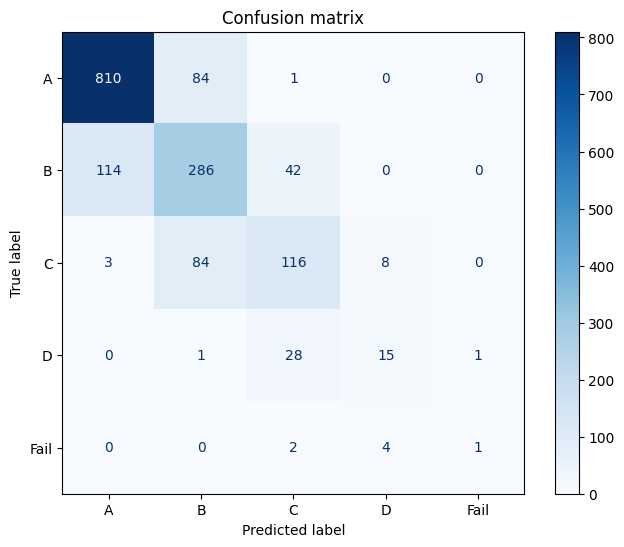

Classification report:
              precision    recall  f1-score   support

           A       0.87      0.91      0.89       895
           B       0.63      0.65      0.64       442
           C       0.61      0.55      0.58       211
           D       0.56      0.33      0.42        45
        Fail       0.50      0.14      0.22         7

    accuracy                           0.77      1600
   macro avg       0.63      0.52      0.55      1600
weighted avg       0.76      0.77      0.76      1600



In [ ]:

try:
    labels = label_encoder.classes_
except NameError:
    labels = None

if 'y_test' in globals() and 'y_pred' in globals():
    if labels is not None:
        cm = confusion_matrix(y_test, y_pred, labels=np.arange(len(labels)))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        fig, ax = plt.subplots(figsize=(8, 6))
        disp.plot(cmap='Blues', ax=ax, values_format='d')
        plt.title('Confusion matrix')
        plt.show()

        print('Classification report:')
        print(classification_report(y_test, y_pred, target_names=labels))
    else:
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        fig, ax = plt.subplots(figsize=(8, 6))
        disp.plot(cmap='Blues', ax=ax, values_format='d')
        plt.title('Confusion matrix')
        plt.show()

        print('Classification report:')
        print(classification_report(y_test, y_pred))
else:
    print('No se encontraron `y_test` y `y_pred`.')

# Conclusion and Result Interpretation

**Observations**:
- There is a majority class (grade A) which shows much higher precision/recall than the minority classes, the model is likely biased due to class imbalance.
- Certain classes are frequently confused with one another (e.g., Fail ↔ C), this may indicate that the current features do not sufficiently distinguish between those labels.

**Practical recommendations:**
- Address class imbalance for minority classes.
- Try non-linear models suggested by a state-of-the-art model
- Validation and tuning: research hyperparameter optimization.
- Interpretability: compute feature importances to understand why certain predictions are being made.


# Framework-based Model
The idea is to implement a model based on a framework from a state-of-the-art paper proposed by **Ma & Xiao (2026)** - [Application of deep learning to the development of a prediction model for college students’ learning outcomes](https://www.scopus.com/pages/publications/105027887338?origin=resultslist)